<a href="https://colab.research.google.com/github/Tanushree-233/mutual-fund-analytics/blob/main/Day2_EDA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn plotly scipy openpyxl -q

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.rcParams["figure.figsize"] = (12,6)
sns.set_style("whitegrid")

# Load datasets
fund_master = pd.read_csv("01_fund_master.csv")
nav_history = pd.read_csv("02_nav_history.csv")
aum = pd.read_csv("03_aum_by_fund_house.csv")
sip = pd.read_csv("04_monthly_sip_inflows.csv")
category = pd.read_csv("05_category_inflows.csv")
folios = pd.read_csv("06_industry_folio_count.csv")
performance = pd.read_csv("07_scheme_performance.csv")
transactions = pd.read_csv("08_investor_transactions.csv")
holdings = pd.read_csv("09_portfolio_holdings.csv")
benchmark = pd.read_csv("10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


# Exploratory Data Analysis (EDA)

This notebook performs exploratory analysis on the Mutual Fund Analytics datasets.

Objectives:
- Analyze NAV trends
- Study AUM growth
- Examine SIP inflows
- Explore investor demographics
- Understand portfolio holdings
- Visualize benchmark performance

In [5]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM": aum,
    "SIP": sip,
    "Category": category,
    "Folios": folios,
    "Performance": performance,
    "Transactions": transactions,
    "Holdings": holdings,
    "Benchmark": benchmark
}

summary = []

for name, df in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicates": df.duplicated().sum()
    })

summary_df = pd.DataFrame(summary)

summary_df

,Dataset,Rows,Columns,Missing Values,Duplicates
0,Fund Master,40,15,0,0
1,NAV History,46000,3,0,0
2,AUM,90,5,0,0
3,SIP,48,6,12,0
4,Category,144,3,0,0
5,Folios,21,6,0,0
6,Performance,40,19,0,0
7,Transactions,32778,13,0,0
8,Holdings,322,8,0,0
9,Benchmark,8050,3,0,0


## Dataset Summary

All datasets were loaded successfully.

Data quality was assessed using:
- Number of rows
- Number of columns
- Missing values
- Duplicate records

# Task 1: NAV Trend Analysis

Objective:
- Plot daily NAV trends for all mutual fund schemes (2022–2026)
- Highlight the 2023 bull market period
- Highlight the 2024 market correction

In [6]:
# Convert date column into datetime format
nav_history["date"] = pd.to_datetime(nav_history["date"])

# Merge scheme names
nav = nav_history.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

nav.head()

,amfi_code,date,nav,scheme_name
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth


In [7]:
import plotly.express as px

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)"
)

# Highlight Bull Run (2023)
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    line_width=0,
    annotation_text="2023 Bull Run",
    annotation_position="top left"
)

# Highlight Market Correction (2024)
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.12,
    line_width=0,
    annotation_text="2024 Correction",
    annotation_position="top right"
)

fig.update_layout(
    height=700,
    template="plotly_white",
    xaxis_title="Date",
    yaxis_title="NAV"
)

fig.show()

In [8]:
fig.write_html("nav_trend.html")

print("NAV Trend chart saved successfully.")

NAV Trend chart saved successfully.


## Insight 1

Daily NAV values generally increased over time, with stronger growth visible during the highlighted 2023 period. Performance varies across schemes, illustrating differences in investment strategies and market exposure.

# Task 2: AUM Growth Analysis

Objective:
- Visualize AUM growth of fund houses from 2022–2025.
- Compare fund houses using grouped bar charts.
- Highlight SBI Mutual Fund's AUM growth.

In [9]:
# Convert date to datetime
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["Year"] = aum["date"].dt.year

# Preview
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,Year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


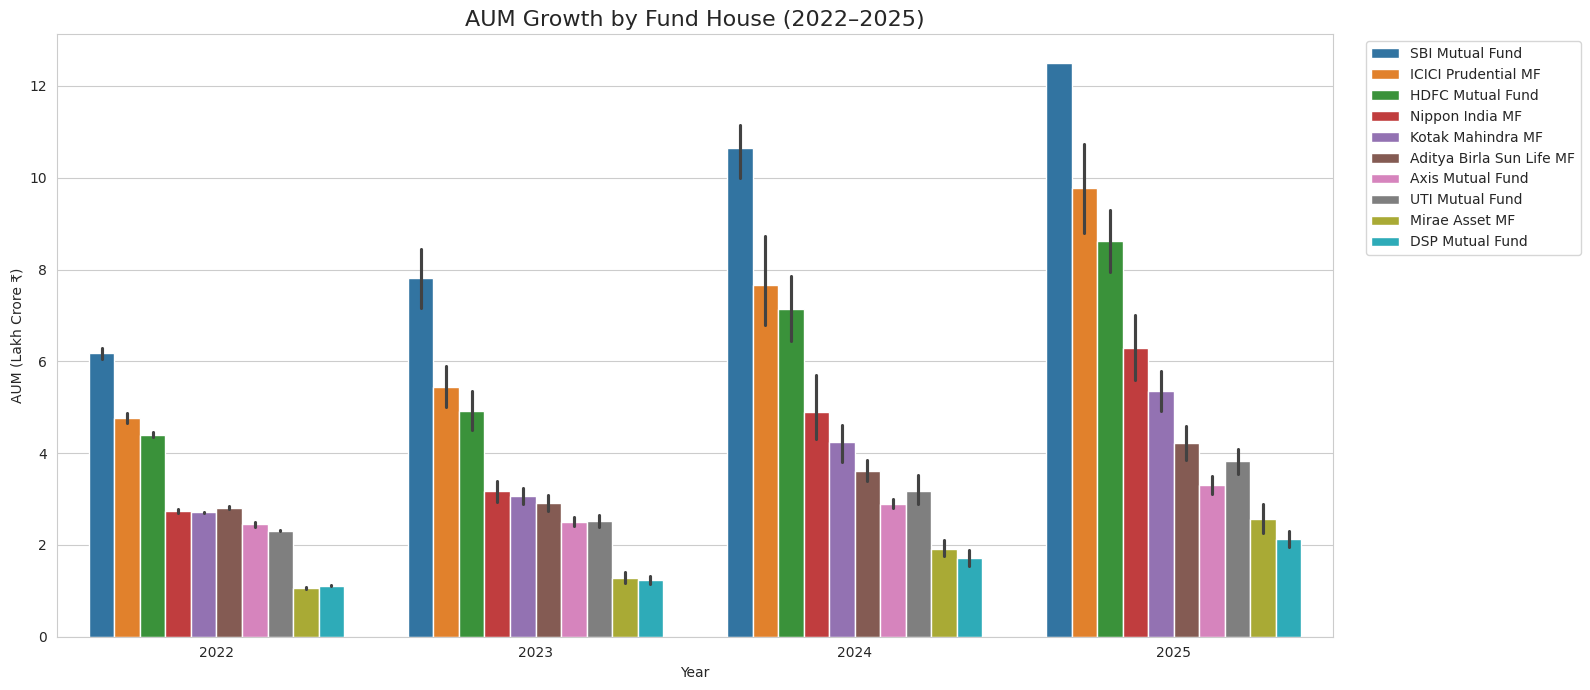

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,7))

sns.barplot(
    data=aum,
    x="Year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")

plt.tight_layout()
plt.show()

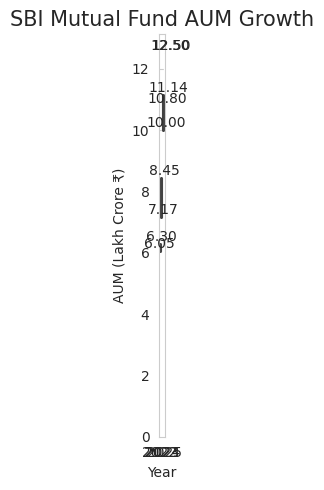

In [11]:
sbi = aum[aum["fund_house"]=="SBI Mutual Fund"]

plt.figure(figsize=(8,5))

sns.barplot(
    data=sbi,
    x="Year",
    y="aum_lakh_crore",
    color="royalblue"
)

plt.title("SBI Mutual Fund AUM Growth", fontsize=15)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore ₹)")

# Annotate values
for i, value in enumerate(sbi["aum_lakh_crore"]):
    plt.text(i, value+0.1, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.savefig("sbi_aum_growth.png", dpi=300)
plt.show()

## Insight 2

SBI Mutual Fund consistently maintained one of the highest Assets Under Management (AUM) across the years, indicating strong investor confidence and market leadership.

# Task 3: Monthly SIP Inflow Trend Analysis

Objective:
- Analyze monthly SIP inflows from January 2022 to December 2025.
- Identify growth trends over time.
- Highlight the highest SIP inflow.

In [12]:
# Convert month column to datetime
sip["month"] = pd.to_datetime(sip["month"])

# Sort data
sip = sip.sort_values("month")

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


In [13]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend (2022–2025)"
)

fig.update_traces(line=dict(width=3))

fig.update_layout(
    template="plotly_white",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)"
)

fig.show()

In [14]:
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f'Highest: ₹{max_row["sip_inflow_crore"]:,} Cr',
    showarrow=True,
    arrowhead=2
)

fig.show()

fig.write_html("sip_inflow_trend.html")

## Insight 3

Monthly SIP inflows show an overall upward trend, indicating increasing investor participation in mutual funds. The highest monthly SIP inflow recorded in the dataset marks a significant milestone in retail investment growth.

# Task 4: Category Inflow Heatmap

## Objective

Visualize monthly net inflows across different mutual fund categories using a heatmap.

This analysis helps identify which categories attracted the highest investor inflows over time.

In [15]:
# Convert month column to datetime
category["month"] = pd.to_datetime(category["month"])

# Create Year-Month format
category["Month"] = category["month"].dt.strftime("%Y-%m")

category.head()

,month,category,net_inflow_crore,Month
0,2024-04-01,Large Cap,2413.0,2024-04
1,2024-04-01,Mid Cap,3897.0,2024-04
2,2024-04-01,Small Cap,3533.0,2024-04
3,2024-04-01,Flexi Cap,4947.0,2024-04
4,2024-04-01,Large & Mid Cap,4214.0,2024-04


In [16]:
pivot_table = category.pivot(
    index="category",
    columns="Month",
    values="net_inflow_crore"
)

pivot_table.head()

Month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


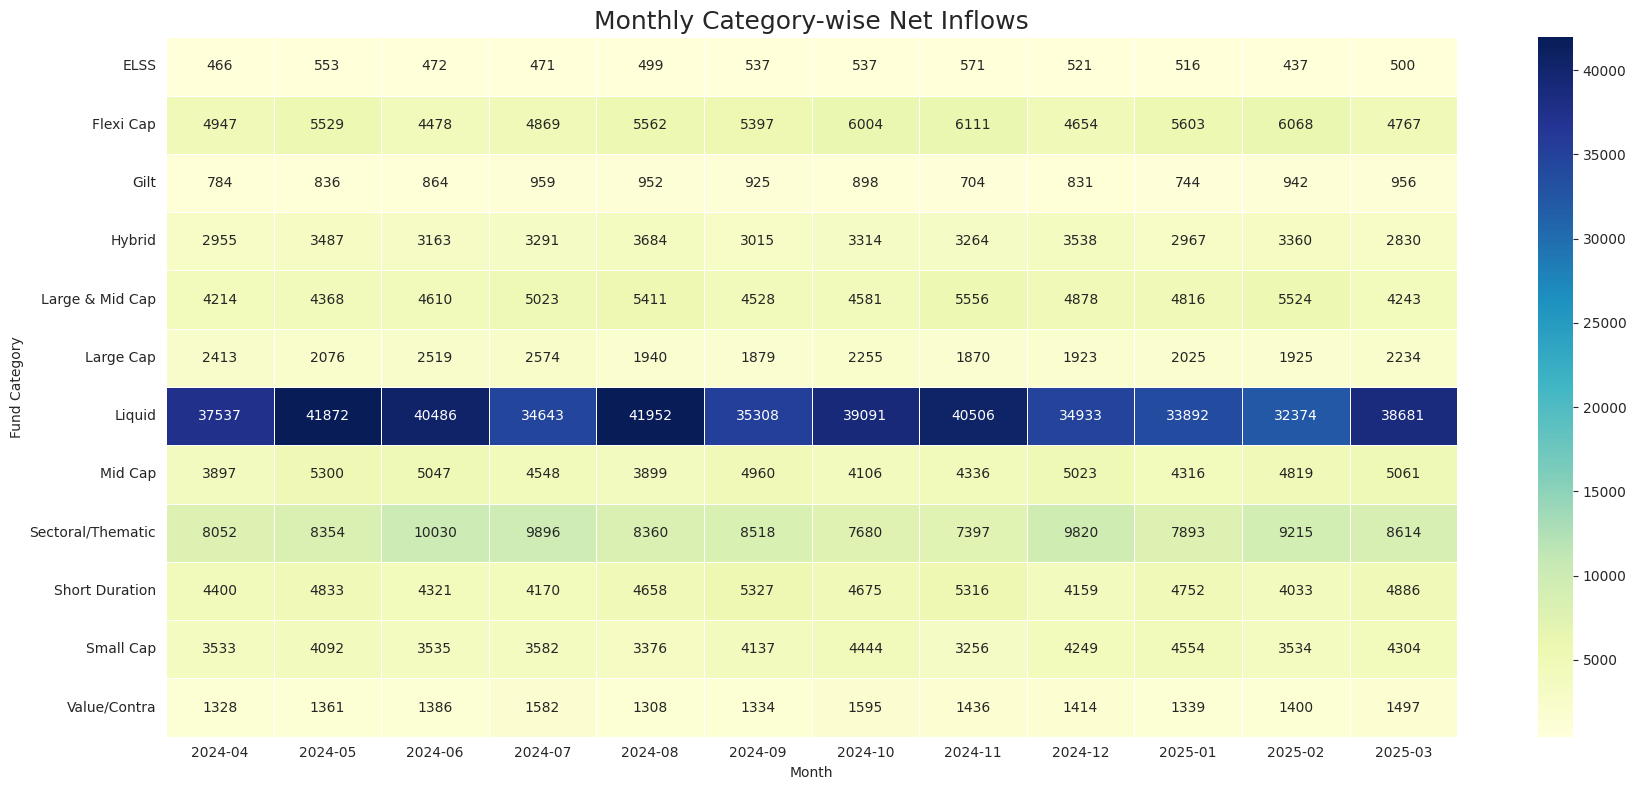

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,8))

sns.heatmap(
    pivot_table,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Monthly Category-wise Net Inflows", fontsize=18)

plt.xlabel("Month")

plt.ylabel("Fund Category")

plt.tight_layout()

plt.savefig("category_inflow_heatmap.png", dpi=300)

plt.show()

## Insight 4

Large Cap, Mid Cap and Flexi Cap categories consistently attracted strong inflows, while some categories experienced lower or negative inflows during certain months. The heatmap clearly highlights seasonal and category-wise investment patterns.

# Task 5: Investor Demographics Analysis

## Objective

Analyze investor demographics using:
- Age Group Distribution
- SIP Amount Distribution
- Gender Distribution

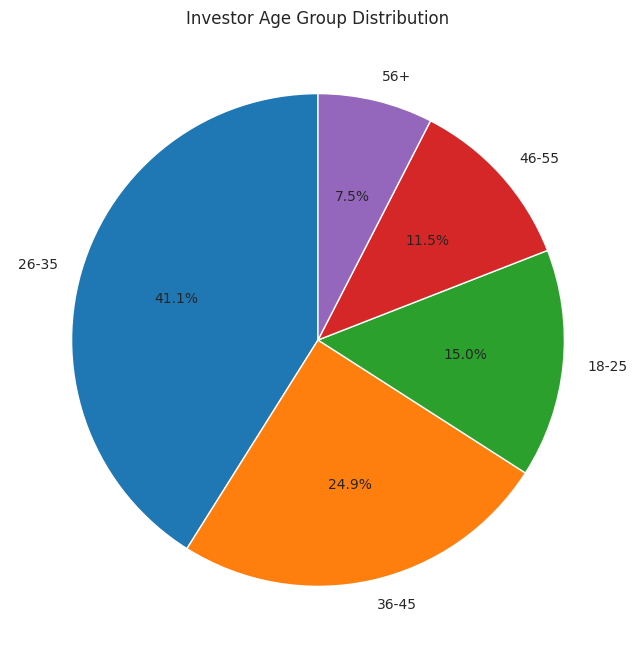

In [18]:
import matplotlib.pyplot as plt

age_counts = transactions["age_group"].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.savefig("age_group_distribution.png", dpi=300)

plt.show()

## Insight 5

The majority of investors belong to the age groups with the highest participation, indicating stronger mutual fund adoption among working-age individuals.

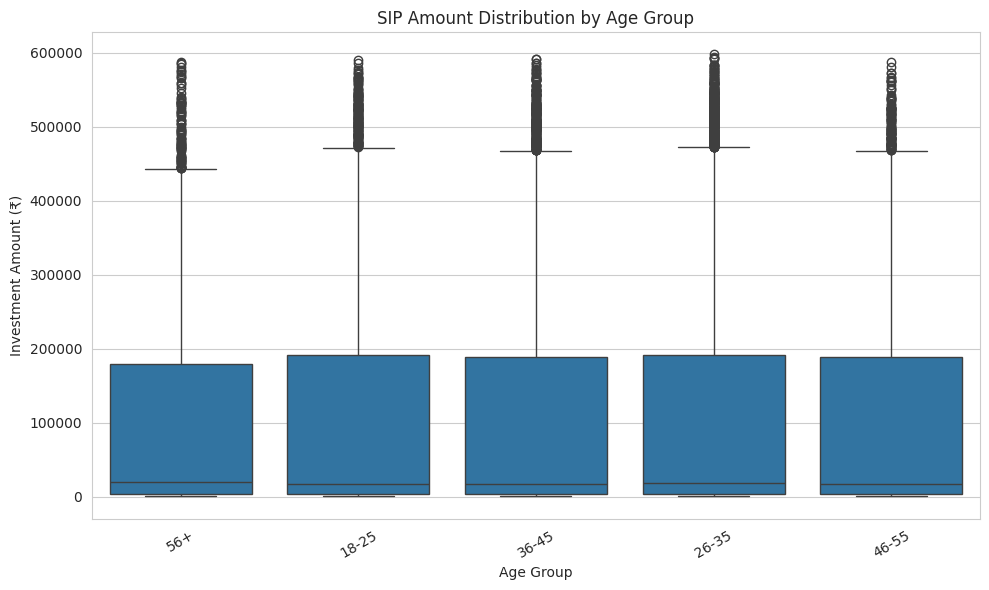

In [19]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Investment Amount (₹)")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig("sip_boxplot_agegroup.png", dpi=300)

plt.show()

## Insight 6

Investment amounts vary across age groups. The box plot helps identify the median investment, spread, and outliers for each age category.

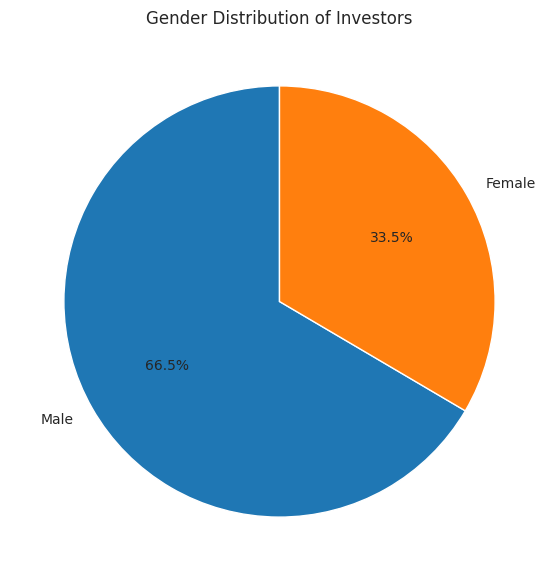

In [20]:
gender = transactions["gender"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution of Investors")

plt.savefig("gender_distribution.png", dpi=300)

plt.show()

## Insight 7

The gender distribution chart illustrates the participation of different genders in mutual fund investments and highlights overall investor diversity.

# Task 6: Geographic Distribution

## Objective

Analyze the geographical distribution of mutual fund investments across different states and city tiers.

Visualizations:
- SIP Amount by State
- T30 vs B30 City Distribution

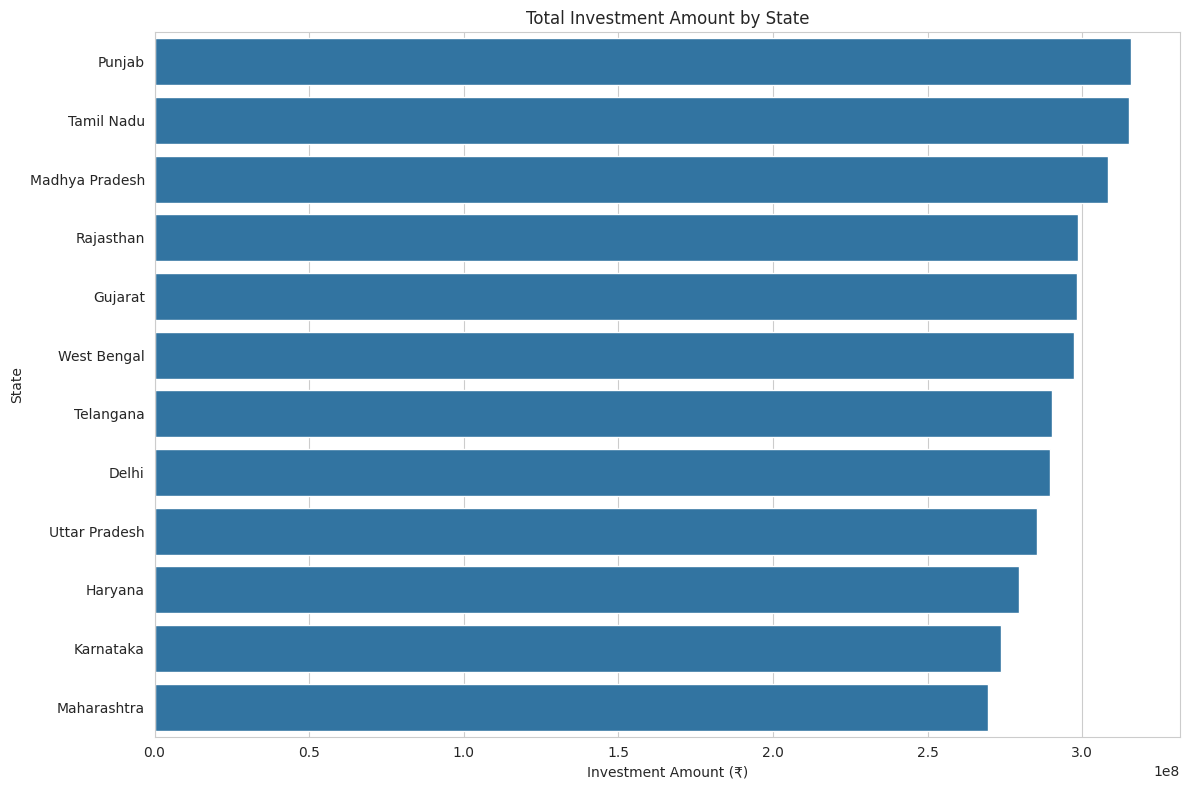

In [21]:
# Total investment amount by state
state_amount = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_amount.values,
    y=state_amount.index
)

plt.title("Total Investment Amount by State")

plt.xlabel("Investment Amount (₹)")

plt.ylabel("State")

plt.tight_layout()

plt.savefig("state_investment.png", dpi=300)

plt.show()

## Insight 8

States with larger investment amounts indicate higher mutual fund participation and stronger financial market penetration.

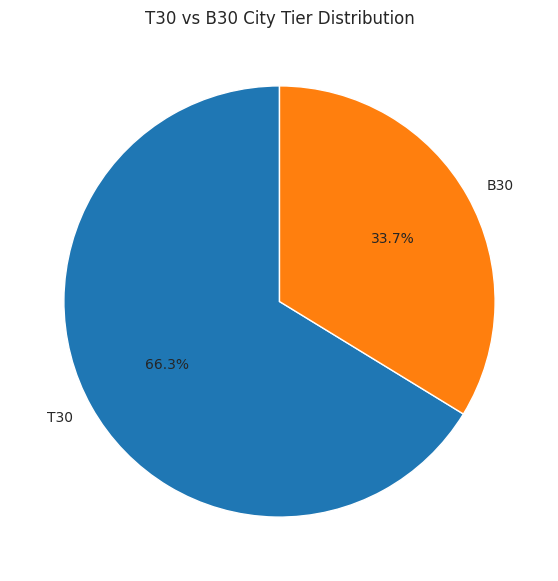

In [22]:
tier = transactions["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 City Tier Distribution")

plt.savefig("city_tier_distribution.png", dpi=300)

plt.show()

## Insight 9

The city-tier distribution shows the contribution of metropolitan (T30) and emerging (B30) cities toward mutual fund investments, highlighting the expanding reach of financial products across India.

# Task 7: Folio Count Growth

## Objective

Analyze the growth in total mutual fund folios over time and identify important milestones.

In [23]:
# Convert month column to datetime
folios["month"] = pd.to_datetime(folios["month"])

# Sort values
folios = folios.sort_values("month")

folios.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01-01,13.26,9.28,1.86,0.80,1.33
1,2022-04-01,13.91,9.74,1.95,0.83,1.39
2,2022-07-01,13.85,9.69,1.94,0.83,1.38
3,2022-10-01,14.12,9.88,1.98,0.85,1.41
4,2023-01-01,14.81,10.37,2.07,0.89,1.48


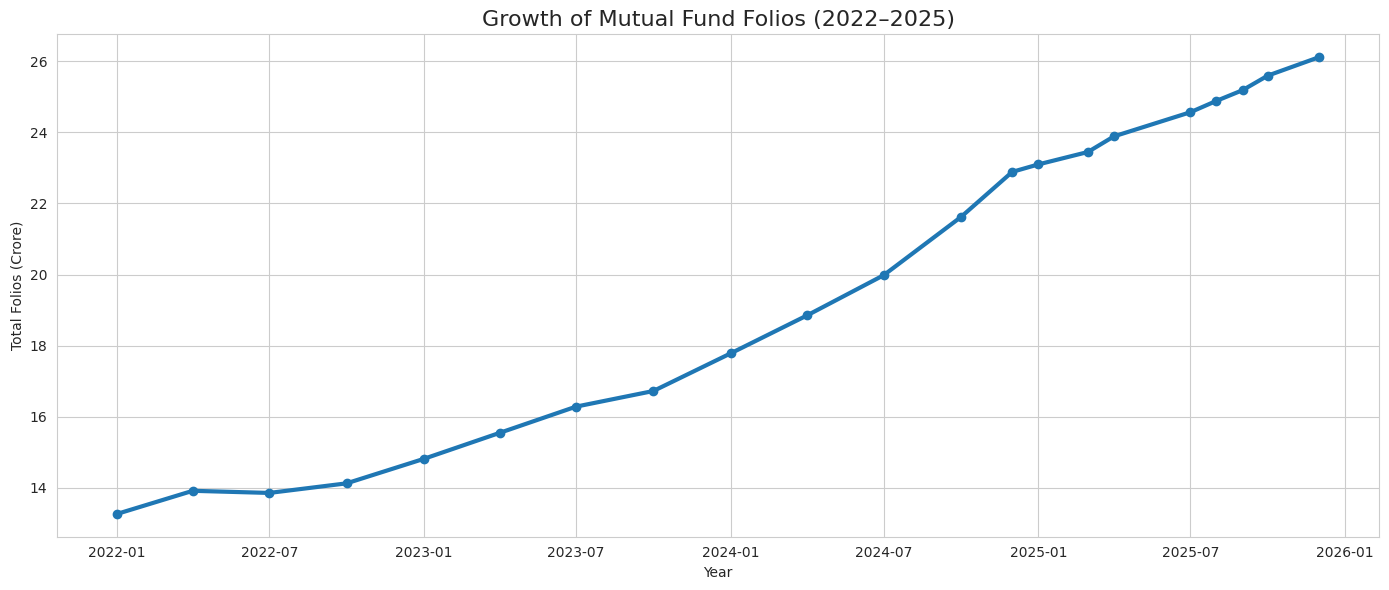

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o",
    linewidth=3
)

plt.title("Growth of Mutual Fund Folios (2022–2025)", fontsize=16)

plt.xlabel("Year")

plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.savefig("folio_growth.png", dpi=300)

plt.show()

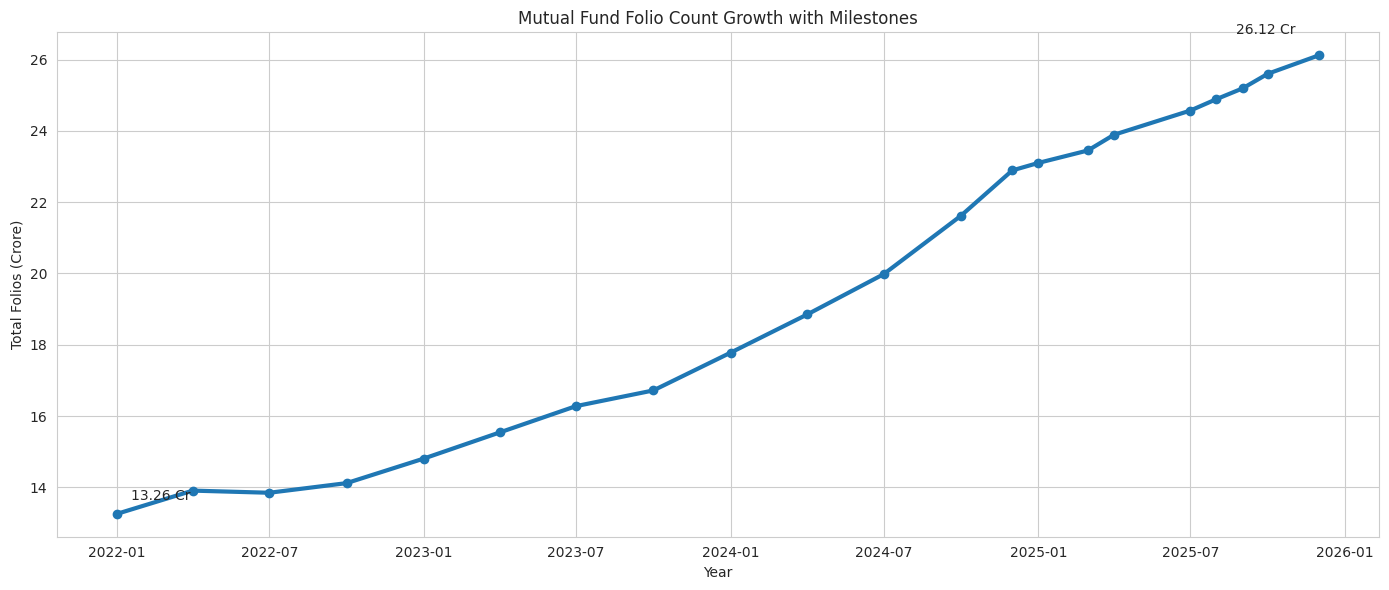

In [25]:
plt.figure(figsize=(14,6))

plt.plot(
    folios["month"],
    folios["total_folios_crore"],
    marker="o",
    linewidth=3
)

# Annotate first point
plt.annotate(
    f'{folios.iloc[0]["total_folios_crore"]:.2f} Cr',
    (folios.iloc[0]["month"], folios.iloc[0]["total_folios_crore"]),
    xytext=(10,10),
    textcoords="offset points"
)

# Annotate last point
plt.annotate(
    f'{folios.iloc[-1]["total_folios_crore"]:.2f} Cr',
    (folios.iloc[-1]["month"], folios.iloc[-1]["total_folios_crore"]),
    xytext=(-60,15),
    textcoords="offset points"
)

plt.title("Mutual Fund Folio Count Growth with Milestones")

plt.xlabel("Year")

plt.ylabel("Total Folios (Crore)")

plt.grid(True)

plt.tight_layout()

plt.savefig("folio_growth_milestones.png", dpi=300)

plt.show()

## Insight 10

The number of mutual fund folios shows a steady upward trend over the observed period, reflecting growing investor participation and increasing adoption of mutual fund investments.

# Task 8: NAV Return Correlation Matrix

## Objective

Analyze the relationship between daily NAV returns of selected mutual fund schemes using a correlation heatmap.

The correlation coefficient ranges from:
- +1 → Strong Positive Correlation
- 0 → No Correlation
- -1 → Strong Negative Correlation

In [26]:
# Select first 10 mutual fund schemes
selected_codes = fund_master["amfi_code"].unique()[:10]

selected_nav = nav_history[
    nav_history["amfi_code"].isin(selected_codes)
].copy()

selected_nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [27]:
selected_nav["date"] = pd.to_datetime(selected_nav["date"])

pivot = selected_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Daily percentage returns
returns = pivot.pct_change().dropna()

returns.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
date,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.002651,-0.000702,-0.018306,-0.014735,-0.018716,0.001001,-0.005010
2022-01-05,0.012865,-0.000050,-0.004386,0.004416,0.006247,-0.005106,-0.005161,-0.001137,0.004250,-0.005184
2022-01-06,-0.011377,-0.001880,-0.005167,0.003598,0.014045,-0.011091,0.004824,-0.007924,-0.003589,-0.002706
2022-01-07,-0.001210,0.002036,-0.005748,-0.002465,-0.001547,0.015111,0.032830,-0.044252,-0.002719,-0.012660
2022-01-10,-0.008639,0.006791,0.006277,-0.000353,-0.001548,0.009465,0.051113,0.033761,0.003057,-0.019536


In [28]:
correlation = returns.corr()

correlation.head()

amfi_code,100016,100025,100033,119120,119551,119552,119598,119599,125497,125498
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,-0.022521,0.040858,0.013663,-0.030296,-0.000007,0.047139,-0.016089
100025,0.045567,1.000000,0.002150,-0.040884,0.017017,-0.002803,-0.065019,-0.034061,0.011326,-0.025505
100033,-0.000006,0.002150,1.000000,-0.007166,-0.015559,-0.027471,0.006659,-0.028323,-0.025137,-0.011916
119120,-0.022521,-0.040884,-0.007166,1.000000,0.021601,-0.004003,0.018423,0.017795,-0.010542,-0.016315
119551,0.040858,0.017017,-0.015559,0.021601,1.000000,-0.006819,0.024409,-0.072559,0.016469,0.030454


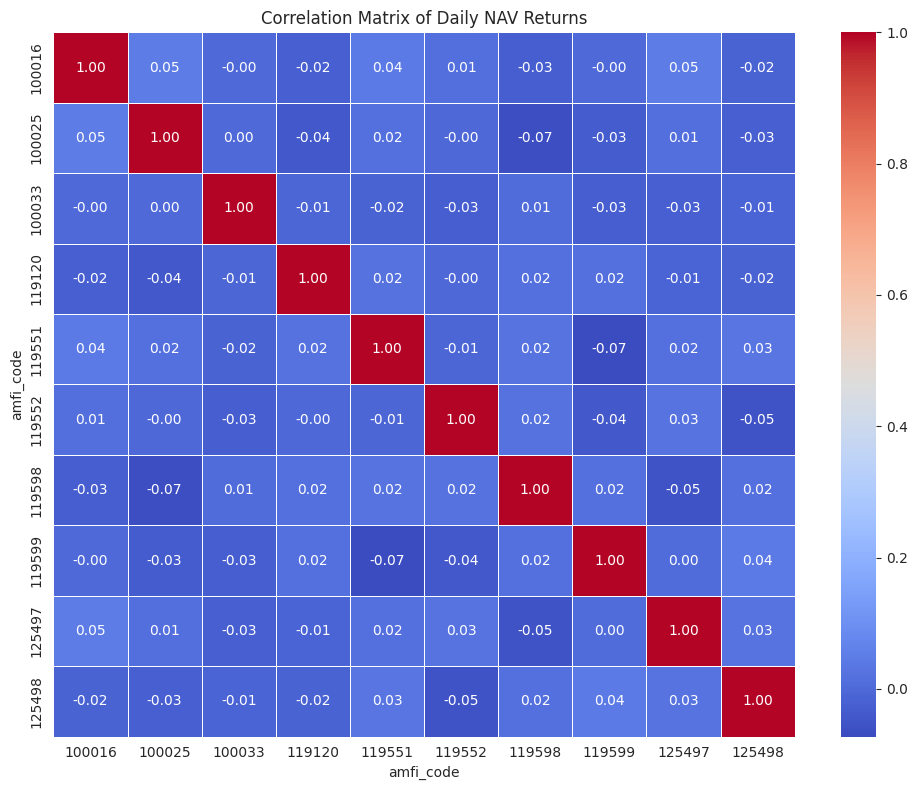

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.tight_layout()

plt.savefig("nav_correlation_heatmap.png", dpi=300)

plt.show()

## Insight 11

The correlation heatmap shows how closely different mutual fund schemes move together. Funds with high positive correlation exhibit similar return patterns, while lower correlations indicate greater diversification potential.

# Task 9: Sector Allocation Analysis

## Objective

Analyze the sector-wise allocation of mutual fund portfolios by aggregating stock weights across all equity funds.

A donut chart is used to visualize the percentage allocation of each sector.

In [30]:
# Aggregate sector weights
sector = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector

,weight_pct
sector,
Banking,652.26
IT,455.47
Pharma,407.45
Automobile,323.65
Utilities,265.54
FMCG,229.11
Infrastructure,192.16
Diversified,169.23
Telecom,145.62


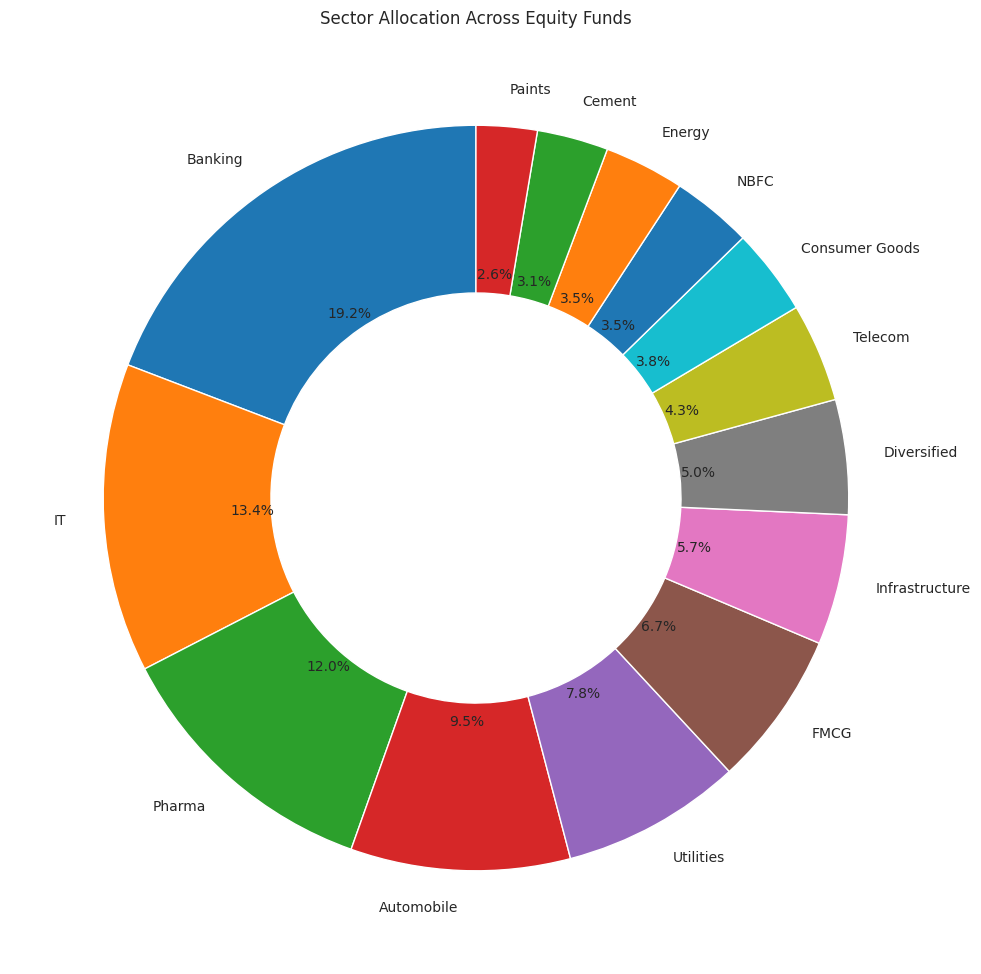

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.45}
)

plt.title("Sector Allocation Across Equity Funds")

plt.tight_layout()

plt.savefig("sector_allocation_donut.png", dpi=300)

plt.show()

## Insight 12

The sector allocation chart shows how mutual fund investments are distributed across different industries. Sectors with higher weight percentages represent larger portfolio exposure and play a significant role in overall fund performance.

# Final EDA Findings

### Insight 1
All 10 datasets were successfully loaded and validated for analysis.

### Insight 2
SBI Mutual Fund consistently maintained one of the highest AUM values among fund houses.

### Insight 3
Monthly SIP inflows show an overall increasing trend, indicating growing investor participation.

### Insight 4
Large Cap, Mid Cap, and Flexi Cap categories attracted strong inflows across multiple months.

### Insight 5
Working-age investors contribute a significant portion of mutual fund investments.

### Insight 6
Investment amounts vary across age groups, with noticeable differences in median and spread.

### Insight 7
The investor base includes participation from multiple genders, showing broad market reach.

### Insight 8
Metropolitan (T30) cities account for a significant share of investments, while B30 cities continue to expand.

### Insight 9
Total mutual fund folios increased steadily during the analysis period, reflecting industry growth.

### Insight 10
Sector allocation analysis highlights diversified investments across multiple industries, reducing concentration risk.